# TP n-body-problem

## Imports de bibliothèques/modules

In [16]:

import numpy as np
import matplotlib.pyplot as plt
import random as rd


## Echauffement au broadcasting :

### 1.

In [17]:

a = np.array([1, 2, 3])

print(np.shape(a[:, None]), np.shape(a[None, :]))

# a[:, None] est un tableau à deux dimensions (sous forme de colonne)
# a[None, :] est un tableau à deux dimensions (sous forme de ligne)

(3, 1) (1, 3)


### 2.

In [18]:

# l'élément sera un tableau à 3 lignes et 3 colonnes, qui correspond à la soustraction
# des matrices constituées des 3 lignes de a[None, :] et des trois colonnes de a[:, None]
print(a[:, None] - a[None, :]) 
# l'élément (i,j) est donc le jème élément de a[:, None] moins le ième de a[None, :]


[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]


### 3.

In [19]:

b = np.arange(6).reshape(2,3)
print(b) # on teste la tête de notre matrice

print(b[:, None, :] , np.shape(b[:, None, :]))

print(b[:, :, None], np.shape(b[:, :, None]))

print(b[:, None, :] - b[:, :, None] , np.shape(b[:, None, :] - b[:, :, None]))
# le résutat correspond à une matrice 3D dont les lignes sont des matrices 3*3,
# issues de la différence entre la première 



[[0 1 2]
 [3 4 5]]
[[[0 1 2]]

 [[3 4 5]]] (2, 1, 3)
[[[0]
  [1]
  [2]]

 [[3]
  [4]
  [5]]] (2, 3, 1)
[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]] (2, 3, 3)


- b[:, None, :] est donc un tableau à trois dimensions dont les deux 'lignes' 
#ont 1 élément chacunes : les lignes de b

-  b[:, :, None] est alors un trableau tridimensionnel dont les lignes (en 2D) sont les lignes de b, mais vues comme des tableaux (1,3) 

-  le résutat de b[:, None, :] - b[:, :, None] correspond à une matrice 3D dont les lignes sont 2 matrices 3*3, issues de la différence entre la première ligne de b[:, None, :] (étirée car à 1 dimension) et la première ligne de b[:, :, None] , vue comme une colonne. On obtient la seconde matrice de la même manière mais avec les deuxième 'lignes'$

- l'élément (i,j,k) est donc le calcul réalisé avec la ième ligne comme expliqué précedemment, et de la différence entre le k_ème élément de la ième ligne de b[:, None, :]  et le jème élément de la ième ligne de b[:, :, None]

## Initialisation aléatoire

In [20]:
# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10.0, 10.0
y_min, y_max = -10.0, 10.0

speed_max = 1.


### Définition de l'initialisation de problème

In [21]:


def init_problem(N):
    masses = np.random.uniform( 0.01, 3, N) # on prend une précision au centième
    positions = np.random.uniform(np.array([[x_min],[y_min]]), np.array([[x_max],[y_max]]), (2,N))
    speeds = np.random.uniform(np.array([[0],[0]]),np.array([[1],[1]]),(2,N)) # on met une vitesse directionelle maximale de 1
    """ renvoie les trois tableaux de donnés, initialisés aléatoirement """
    return masses, positions, speeds

masses, positions, speeds = init_problem(10)

try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("HOURRA")
except:
    print("KO")



HOURRA


### Initialisation reproductible

In [22]:
def init3():
    # first element is sun-like: heavy, at the center (sun-like), and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    """ Crée une situation initiale aléatoire """
    return masses, positions, speeds


## Les forces

In [23]:
def forces(masses, positions, G=1.0):
    diff_vect = positions[:,:,None] - positions[:,None,:]
    dist = np.linalg.norm(diff_vect,axis=0)
    np.fill_diagonal(dist,np.inf)
    produit_masses_G = G * masses[:,None] * masses[None,:]
    forces_appliquées = produit_masses_G[None,:,:]*diff_vect / ((dist[None,:,:])**3)
    forces_totales = np.sum(forces_appliquées , axis = 1 )
    """
    returns an array of shape (2,  N)
    that contains the force felt by each mass from all the others
    G is the Newton constant and by default is set to 1 
    (we have abstract units anyway)
    """
    return forces_totales



#### Explications :

- diff_ vect = on fait le même type de différence qu'en question 2 pour obtenir la taille demandée (broadcasting)

- utilisation de linalg.norm pour le calcul des distances : linalg.norm prend en paramètre notre tableau, ainsi que l'axe de calcul pour les normes (la première ligne étant les abscisses et la seconde les ordonnées pour notre tableau de taille (2,N,N)). On obtient alors un ndarray qui est le tableau des différentes normes.

- np.fill_diagonal : on s'assure que les valeurs de distance sur notre diagonale, normalement nulle, ne le soient pas pour que, lorsque nous allons diviser par la valeur, nous n'ayons pas un problème. Pour y remédier, on choisit une valeur telle que tout float divisé par cette valeur donne un résultat nul (permettrait de ne pas prendre en compte l'auto-intéraction) ; soit np.inf ('1/inf = 0')
    
- forces_appliquées : on a réutilisé le principe de broadcasting pour avoir des tableaux de dimensions cohérentes pour le calcul.

- forces_totales : on somme notre tableau à 3 dimensions sur les lignes pour obtenir une somme sur les indices (la composante i=j ayant été rendue négligeable)

#### Test

In [24]:
masses, positions, speeds = init3()
f = forces(masses, positions)
np.all(np.isclose(f, np.array([
     [ 0.        , -0.12257258,  0.12257258],
     [ 0.        , -0.02451452,  0.02451452]])))

np.True_

## Simulateur

In [25]:
def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    dim = len(positions)
    N = len(masses)
    résultat = np.zeros((nb_steps, dim, N))
    masse_broad = masses[None,:]
    for i in range(nb_steps):
        résultat[i]=positions
        F = forces(masses,positions)
        accélération = forces(masses,positions) / masse_broad 
        speeds=speeds + accélération*dt
        positions=positions + speeds*dt
    résultat[-1]=positions 
    return résultat
    """
        should return the positions across time
        so an array of shape (nb_steps, 2, N)
        optional dt is the time step   """


#### Explications :

On utilise le second principe de la dynamique newtonienne
Pour l'accélération, il faut broadcaster le tableau de masses pour le rendre opérable par les forces, donc l'étendre.

#### Test d'affichage

In [30]:
simulation = simulate(init3()[0],init3()[1],init3()[2])
print(simulation)

# pour vérifier si le code est bon

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")

positions1 = s[1]

np.all(np.isclose(positions1, np.array([
     [ 0.        ,  4.89877427, -4.89877427],
    [ 0.        ,  0.99975485, -0.99975485]
 ])))




[[[ 0.          5.         -5.        ]
  [ 0.          1.         -1.        ]]

 [[ 0.          4.89877427 -4.89877427]
  [ 0.          0.99975485 -0.99975485]]

 [[ 0.          4.79627468 -4.79627468]
  [ 0.          0.99924973 -0.99924973]]

 [[ 0.          4.69244953 -4.69244953]
  [ 0.          0.99846845 -0.99846845]]

 [[ 0.          4.58724324 -4.58724324]
  [ 0.          0.99739329 -0.99739329]]

 [[ 0.          4.48059587 -4.48059587]
  [ 0.          0.99600479 -0.99600479]]

 [[ 0.          4.37244262 -4.37244262]
  [ 0.          0.99428155 -0.99428155]]

 [[ 0.          4.26271324 -4.26271324]
  [ 0.          0.99219989 -0.99219989]]

 [[ 0.          4.15133136 -4.15133136]
  [ 0.          0.98973361 -0.98973361]]

 [[ 0.          4.03821371 -4.03821371]
  [ 0.          0.98685348 -0.98685348]]

 [[ 0.          3.92326914 -3.92326914]
  [ 0.          0.9835269  -0.9835269 ]]

 [[ 0.          3.80639758 -3.80639758]
  [ 0.          0.97971724 -0.97971724]]

 [[ 0.          

np.True_

## Affichage graphique

In [28]:
def dessin(simulation, masses, colors=None, scale=10.):
    fig, ax = plt.subplots()
    for i in range(len(masses)):
        abscisses=simulation[:,:,i].T[0]
        ordonnées=simulation[:,:,i].T[1]
        ax.scatter(abscisses[-1],ordonnées[-1], s=30*masses[i])
        if colors is not None:
            ax.scatter(abscisses[-1], ordonnées[-1], s=30 * masses[i], color=colors[i])
            plt.plot(abscisses,ordonnées,color=colors[i])
        else:
            ax.scatter(abscisses[-1],ordonnées[-1], s=30*masses[i])
            plt.plot(abscisses,ordonnées)
    """
        takes as input the result of simulate() above,
        and draws the nb_steps positions of each of the N bodies
        ideally it should return a matplotlib Axes object
    
        one can provide a collection of N colors to use for each body
        if not provided this is randomized
    
        also the optional scale parameter is used as a constant
        multiplier to obtain the final size of each dot on the figure
        """
    plt.show()

#### Test :


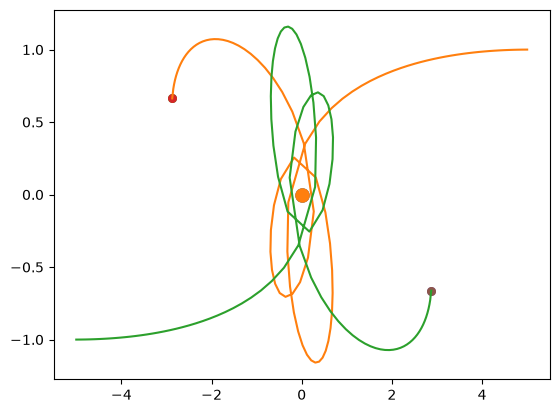

In [31]:
dessin(simulation,init3()[0])

### On crée une liste de couleurs

In [37]:
colors_init = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255


### On finalise le programme en assemblant :

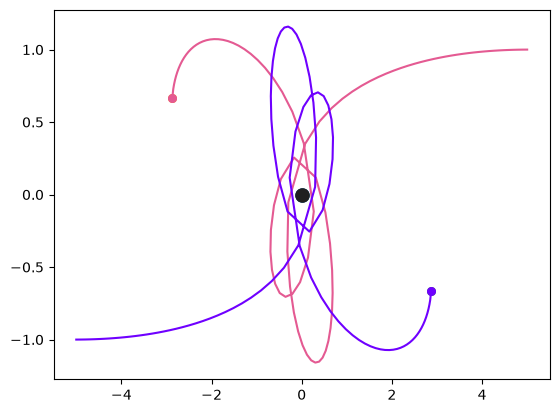

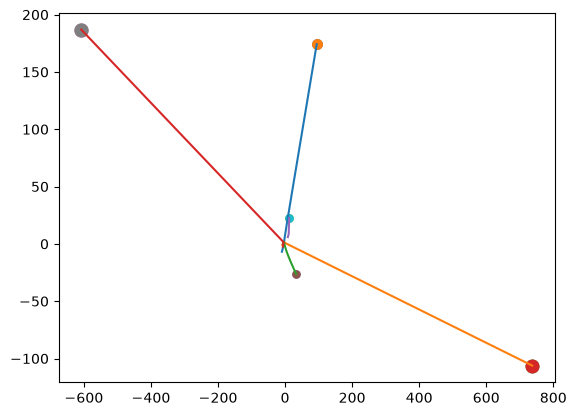

<Figure size 640x480 with 0 Axes>

In [39]:
masses, positions, speeds = init3()
dessin(simulate(masses, positions, speeds), masses, colors_init)

m1, p1, s1 = init_problem(5)
sim = simulate(m1, p1, s1, nb_steps=1000)
dessin(sim, m1, scale=3) ;
plt.savefig("image.png")
